# Classification using Tensorflow

In [1]:
import tensorflow as tf

In [2]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

import pandas as pd
circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})

circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


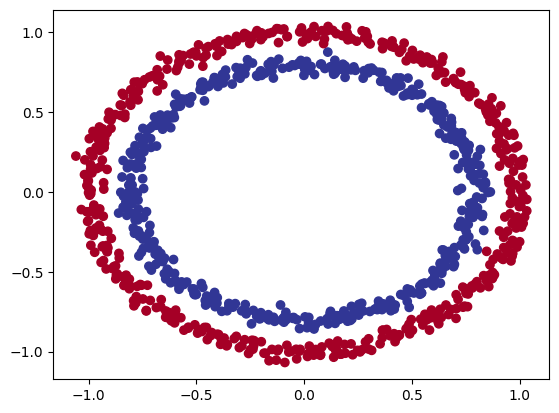

In [3]:
from matplotlib.colors import Colormap
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [4]:
## Building a Model
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history = model.fit(X, y, epochs=100, verbose=0)

In [5]:
# Creating Model 1 Traning for longer
model.fit(X, y, epochs=200, verbose=0)
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 0.6932  


[0.6932491064071655, 0.48399999737739563]

In [6]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_1 = model_1.fit(X, y, epochs=100, verbose=0)
model_1.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4910 - loss: 0.6949


[0.6949362754821777, 0.4909999966621399]

In [7]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy'])

history_2 = model_2.fit(X, y, epochs=100, verbose=0)
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0045


[0.004468546714633703, 1.0]

In [8]:
# Function to visualize the decision boundary of a trained model
def plot_decision_boundary(model, X, y):
  import numpy as np
  import matplotlib.pyplot as plt
  import tensorflow as tf # Import tensorflow for tf.squeeze if not already imported globally

  # Define the axis boundaries of the plot based on the input data X
  # We add a small margin (0.1) to ensure all data points are visible.
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

  # Create a meshgrid: This generates a grid of points (xx, yy) over the entire plot area.
  # The model will make predictions for each of these points to draw the decision boundary.
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100))

  # Prepare input for the model: This converts the 2D grid points into a flat array of (x, y) coordinates.
  # Fix 1: The original code `np.c_[[xx.ravel(), yy.ravel()]]` created a shape (2, 10000)
  # (2 samples, 10000 features each). The model expects (number_of_samples, number_of_features),
  # so it should be (10000, 2). Removing the outer list `[]` corrects this.
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # Make predictions on the grid points using the provided model.
  y_pred = model.predict(x_in)

  # Process predictions to get class labels and reshape them back to the grid shape.
  # This is crucial for plotting the decision regions.
  if y_pred.shape[-1] == 1: # This condition typically indicates binary classification (single output neuron)
    # For binary classification, model.predict often outputs probabilities (e.g., between 0 and 1).
    # We convert these probabilities to class labels (0 or 1) by applying a threshold (e.g., 0.5).
    # tf.squeeze removes single-dimensional entries from the shape of an array.
    p_pred = (tf.squeeze(y_pred) > 0.5).numpy().reshape(xx.shape)
  else: # This condition handles multi-class classification (multiple output neurons with softmax)
    # In multi-class, we take the index of the highest probability as the predicted class.
    print("doing multiclass classification") # Original print statement kept for context
    p_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)

  # Plot the decision boundary.
  # Fix 2: Typo - `plt.countourf` should be `plt.contourf`.
  # Fix 3: The third argument to `contourf` should be `p_pred` (the model's predictions on the grid),
  # not `y` (the original true labels). Plotting `y` would show contours based on the original data distribution,
  # not the model's learned decision regions.
  plt.contourf(xx, yy, p_pred, cmap=plt.cm.RdYlBu, alpha=0.7)

  # Plot the original data points on top of the decision boundary.
  # `c=y` colors the points according to their true labels.
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)

  # Set plot limits to match the meshgrid boundaries.
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

  # Display the plot.
  plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


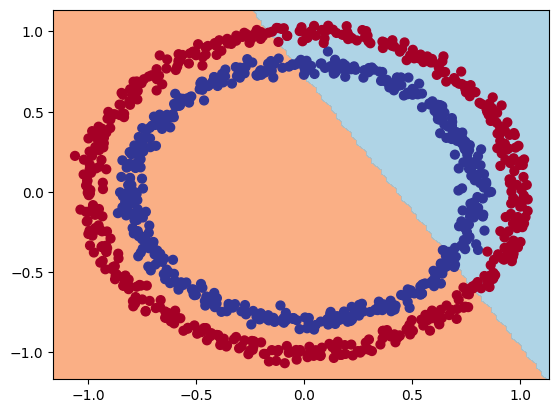

In [9]:
plot_decision_boundary(model, X, y)

## Introduction to non-linearity


In [10]:
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear),
])

model_4.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_4 = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4830 - loss: 6.4541
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 6.4499 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 6.4382 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.4352 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.4326 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.4313 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.4301 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.4289 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.4277 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 6.3766 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4810 - loss: 6.3439 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


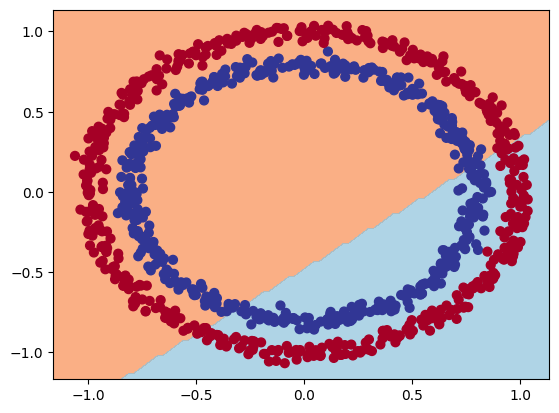

In [11]:
plot_decision_boundary(model_4, X, y)

In [12]:
tf.random.set_seed(42)

model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

history_5 = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4970 - loss: 4.4647
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4720 - loss: 4.2900
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4410 - loss: 4.1426
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4200 - loss: 4.0106 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4150 - loss: 3.8763 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4100 - loss: 3.7841 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4060 - loss: 3.7149 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4080 - loss: 3.6809 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4130 - loss: 3.6464 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4230 - loss: 3.5193 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4240 - loss: 3.3506
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - ac

In [13]:
model_5.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.7193  


[0.7193325757980347, 0.5]

In [14]:
tf.random.set_seed(42)

model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
])


model_6.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

history_6 = model_6.fit(X, y, epochs=200, verbose=0)

The important of activation in the output layer? and also in other layers? and what are the activations to use?

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9810 - loss: 0.0720 
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


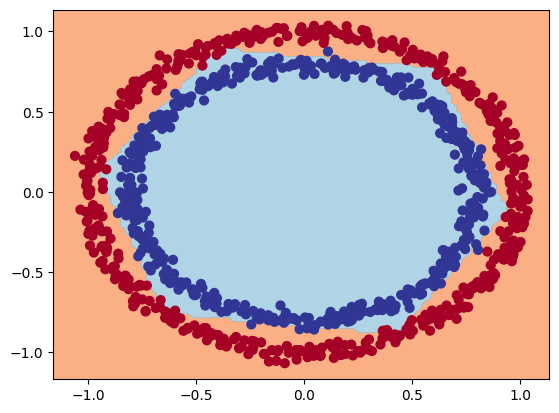

In [23]:
model_6.evaluate(X, y)

plot_decision_boundary(model_6, X, y)

In [24]:
tf.random.set_seed(42)

model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

model_7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy']) # Changed tf.keras.metrics.Accuracy() to 'accuracy'

history_7 = model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4980 - loss: 0.6927
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5050 - loss: 0.6924
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5060 - loss: 0.6922
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5040 - loss: 0.6920
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5060 - loss: 0.6919
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5050 - loss: 0.6917
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5050 - loss: 0.6915
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5050 - loss: 0.6914
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5040 - loss: 0.6912
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5050 - loss: 0.6910
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5060 - loss: 0.6908
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9070 - loss: 0.4021  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


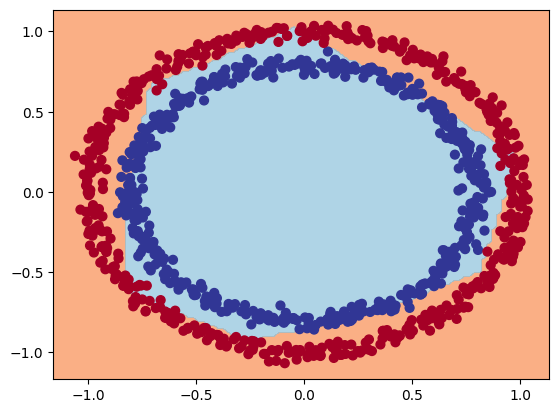

In [25]:
model_7.evaluate(X, y)

plot_decision_boundary(model_7, X, y)

The combination of linear and non-linear functions is one of the key fundamentals of neural network. IN the Relu and Sigmoid note, transform a normal tensor vector into relu and plot?

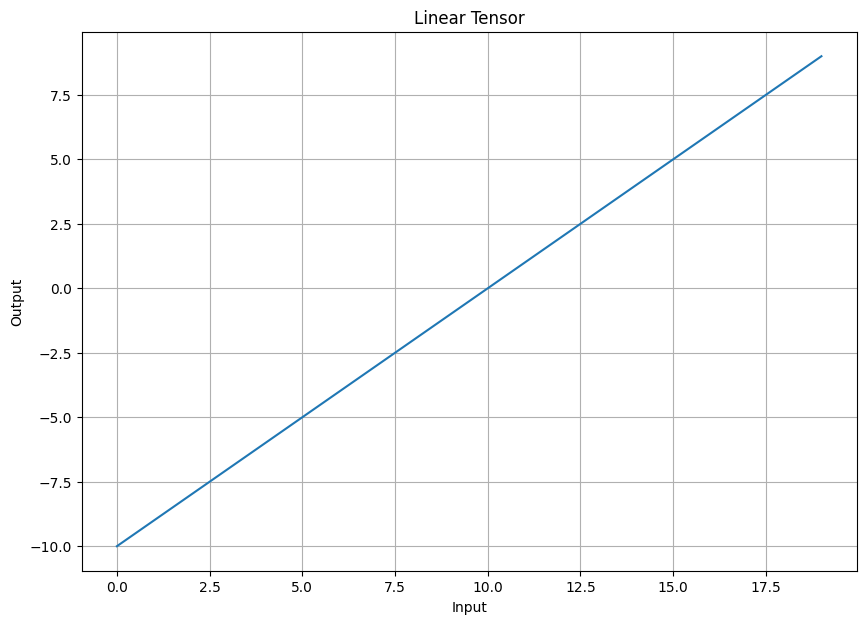

<Figure size 640x480 with 0 Axes>

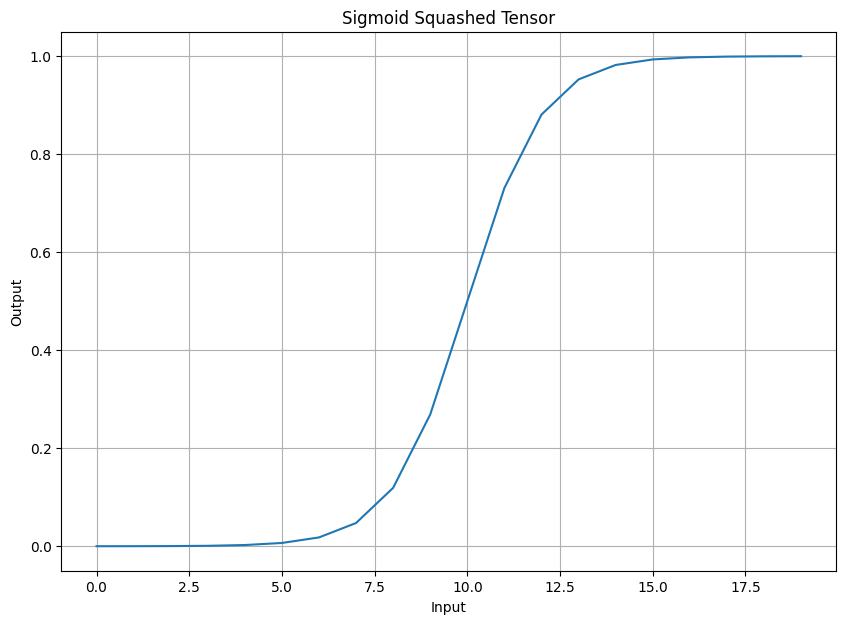

<Figure size 640x480 with 0 Axes>

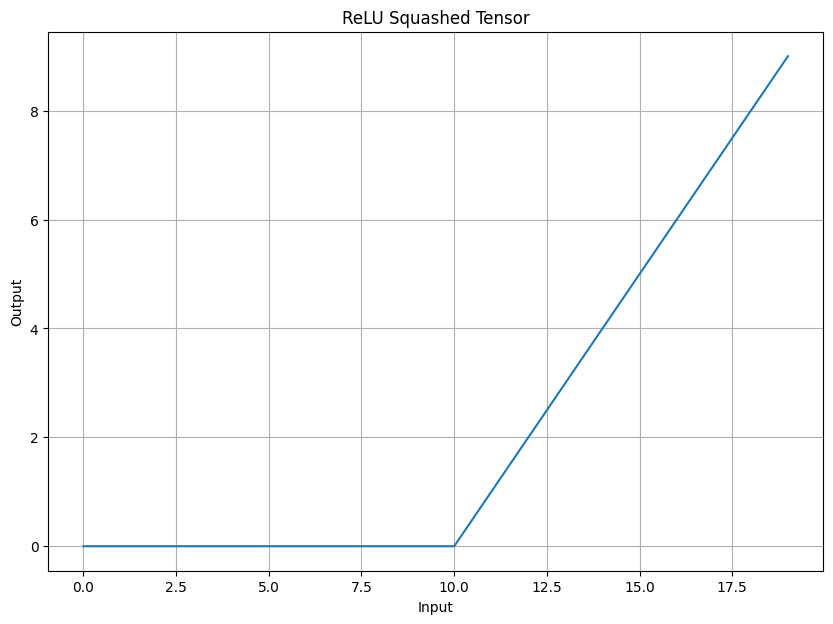

<Figure size 640x480 with 0 Axes>

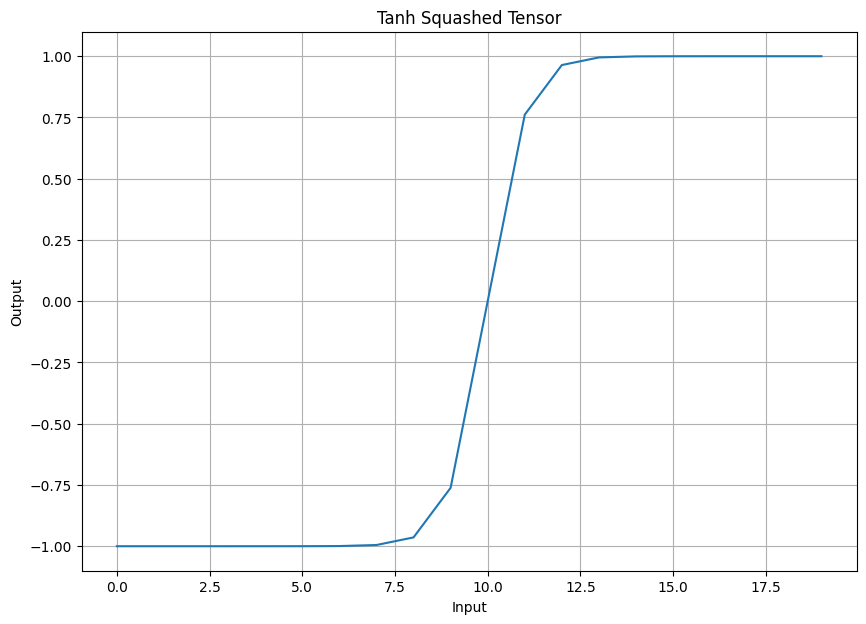

<Figure size 640x480 with 0 Axes>

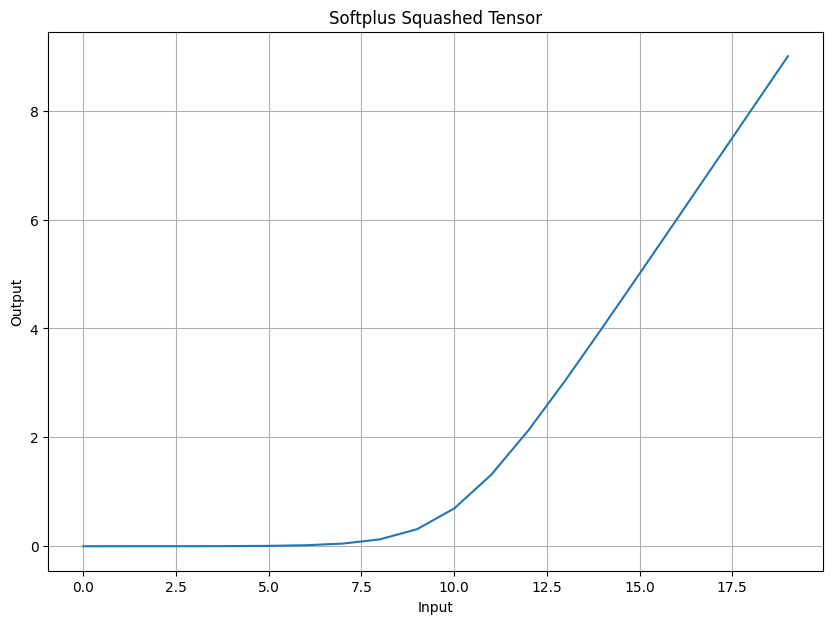

<Figure size 640x480 with 0 Axes>

In [32]:
import matplotlib.pyplot as plt
import tensorflow as tf # Ensure tf is imported for activation functions

linear_line = tf.cast(tf.range(-10, 10), tf.float32)

# Plot Linear Tensor
plt.figure(figsize=(10, 7))
plt.plot(linear_line)
plt.title("Linear Tensor")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()
plt.savefig("linear.png")

# Create a sigmoid squashing of the tensor
sigmoid = tf.math.sigmoid(linear_line)
plt.figure(figsize=(10, 7))
plt.plot(sigmoid)
plt.title("Sigmoid Squashed Tensor")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()
plt.savefig("sigmoid.png")

# Create ReLU squashing of the tensor
relu = tf.math.maximum(0, linear_line)
plt.figure(figsize=(10, 7))
plt.plot(relu)
plt.title("ReLU Squashed Tensor")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()
plt.savefig("relu.png")

# Create Tanh squashing of the tensor
tanh = tf.math.tanh(linear_line)
plt.figure(figsize=(10, 7))
plt.plot(tanh)
plt.title("Tanh Squashed Tensor")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()
plt.savefig("tanh.png")

# Create Softplus squashing of the tensor
softplus = tf.math.softplus(linear_line)
plt.figure(figsize=(10, 7))
plt.plot(softplus)
plt.title("Softplus Squashed Tensor")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()
plt.savefig("softplus.png")

In [33]:
## Evaluating and improving our classification

len(X)

1000

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((750, 2), (250, 2), (750,), (250,))

What is learning rate and how it actually improves a mdoels learning?

In [43]:
# Training and Testing

tf.random.set_seed(42)

callback = tf.keras.callbacks.EarlyStopping(
    monitor="accuracy",
    patience=10,
    restore_best_weights=True
)

final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

final_model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    metrics=['accuracy'])

final_model.fit(X_train, y_train, epochs=200, callbacks=[callback])

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5200 - loss: 0.6881
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5653 - loss: 0.6819
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5733 - loss: 0.6746
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5853 - loss: 0.6635
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6093 - loss: 0.6474
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6933 - loss: 0.6247  
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7493 - loss: 0.5966 
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7733 - loss: 0.5664 
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.5345 
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8427 - loss: 0.4937 
Epoch 11/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8933 - loss: 0.4522 
Epoch 12/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ac

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9840 - loss: 0.1472  
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


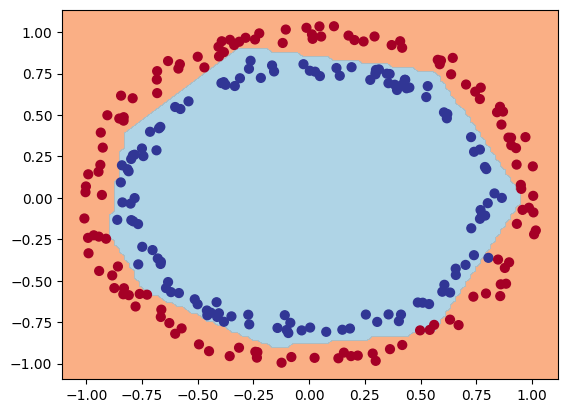

In [44]:
final_model.evaluate(X_test, y_test)
plot_decision_boundary(final_model, X_test, y_test)